# P13 - Evaluation des modeles ML

Benchmark des modeles candidats sur les 3 cibles du projet.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

if Path('/app/src').exists():
    sys.path.insert(0, '/app/src')
else:
    sys.path.insert(0, '../../src')

from p13.db import read_sql
from p13.ml.features import ALL_TARGETS, FEATURE_COLUMNS
from p13.ml.train import get_model_candidates

In [2]:
df = read_sql('SELECT * FROM ml_dataset_commune WHERE nb_eleves_maternelle IS NOT NULL')
df = df.dropna(subset=FEATURE_COLUMNS + ALL_TARGETS).copy()

if len(df) < 20:
    raise ValueError(f'Dataset trop petit pour benchmark robuste: {len(df)} lignes')

df.shape

(688, 17)

In [3]:
def metrics(y_true, y_pred):
    mape_mask = y_true != 0
    mape = float(np.mean(np.abs((y_true[mape_mask] - y_pred[mape_mask]) / y_true[mape_mask])) * 100) if mape_mask.any() else 0.0
    return {
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'r2': float(r2_score(y_true, y_pred)),
        'mape': mape
    }

## Métriques d'évaluation — définitions

Les 4 métriques calculées mesurent la qualité des prédictions sur le jeu de test (20% des données) :

| Métrique | Formule | Interprétation |
|---|---|---|
| **R²** (coefficient de détermination) | 1 − SS_res/SS_tot | Proportion de variance expliquée. **1.0 = parfait**, 0 = pas mieux que la moyenne, <0 = pire que la moyenne. Viser > 0.90. |
| **RMSE** (Root Mean Squared Error) | √(moyenne des (ŷ − y)²) | Erreur moyenne en **unité de la cible** (élèves ou classes). Pénalise fortement les grandes erreurs. |
| **MAE** (Mean Absolute Error) | moyenne de |ŷ − y| | Erreur absolue moyenne. Plus robuste aux outliers que le RMSE. |
| **MAPE** (Mean Absolute Percentage Error) | moyenne de |ŷ − y| / y × 100 | Erreur relative en %. Facilite la comparaison entre cibles d'échelles différentes. Attention : instable si y ≈ 0. |

> La **Cross-Validation R²** (cv_r2_mean) évalue la stabilité du modèle sur 5 sous-ensembles : un écart important entre R² test et cv_r2 signale du surapprentissage.

In [4]:
rows = []
X = df[FEATURE_COLUMNS].values

for target in ALL_TARGETS:
    y = df[target].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    for model_name, model in get_model_candidates().items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        m = metrics(y_test, y_pred)
        rows.append({'target': target, 'model': model_name, **m})

results = pd.DataFrame(rows).sort_values(['target', 'r2'], ascending=[True, False])
results

,target,model,rmse,mae,r2,mape
10,nb_classes,random_forest,14.872937,4.793195,0.989293,10.277437
11,nb_classes,gradient_boosting,14.940800,4.837825,0.989196,10.280111
8,nb_classes,linear_regression,15.258135,5.708220,0.988732,18.002147
9,nb_classes,ridge,15.287040,5.713388,0.988689,17.842569
7,nb_eleves_elementaire,gradient_boosting,159.348725,59.174943,0.993146,9.474619
6,nb_eleves_elementaire,random_forest,159.496088,58.712973,0.993133,9.415800
4,nb_eleves_elementaire,linear_regression,168.947754,82.421153,0.992295,27.853920
5,nb_eleves_elementaire,ridge,169.100626,82.770140,0.992281,28.106222
2,nb_eleves_maternelle,random_forest,53.254280,27.535604,0.998437,11.466009
3,nb_eleves_maternelle,gradient_boosting,53.738102,27.471558,0.998409,11.365173


## Lecture du tableau de benchmark

Le tableau ci-dessus compare les 4 modèles sur les 3 cibles. Pour chaque cible, les lignes sont triées par R² décroissant (meilleur en haut).

**Comment lire les résultats :**

- Un R² > 0.98 sur un jeu de données aussi petit (quelques dizaines de communes) doit être interprété avec prudence : le modèle apprend bien mais le risque de surapprentissage est réel — vérifier le cv_r2.
- Le RMSE sur `nb_eleves_elementaire` sera naturellement plus élevé que sur `nb_classes` car les échelles sont différentes (centaines d'élèves vs dizaines de classes).
- **Régression linéaire et Ridge** servent de **baseline** : si un modèle plus complexe ne fait pas mieux, la relation est linéaire et le modèle simple est préférable (interprétabilité, rapidité).
- **Random Forest** et **Gradient Boosting** capturent les non-linéarités mais sont des boîtes noires — d'où l'intérêt des analyses SHAP du notebook 02.

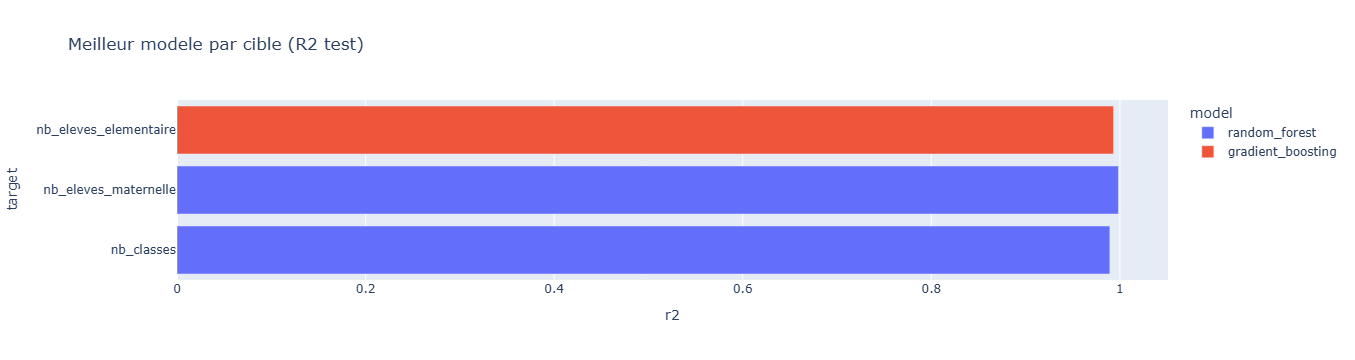

,target,model,rmse,mae,r2,mape
10,nb_classes,random_forest,14.872937,4.793195,0.989293,10.277437
7,nb_eleves_elementaire,gradient_boosting,159.348725,59.174943,0.993146,9.474619
2,nb_eleves_maternelle,random_forest,53.254280,27.535604,0.998437,11.466009


In [5]:
best = results.loc[results.groupby('target')['r2'].idxmax()].copy()
best = best.sort_values('r2', ascending=True)

fig = px.bar(
    best,
    x='r2',
    y='target',
    color='model',
    orientation='h',
    title='Meilleur modele par cible (R2 test)'
)
fig.show()
best

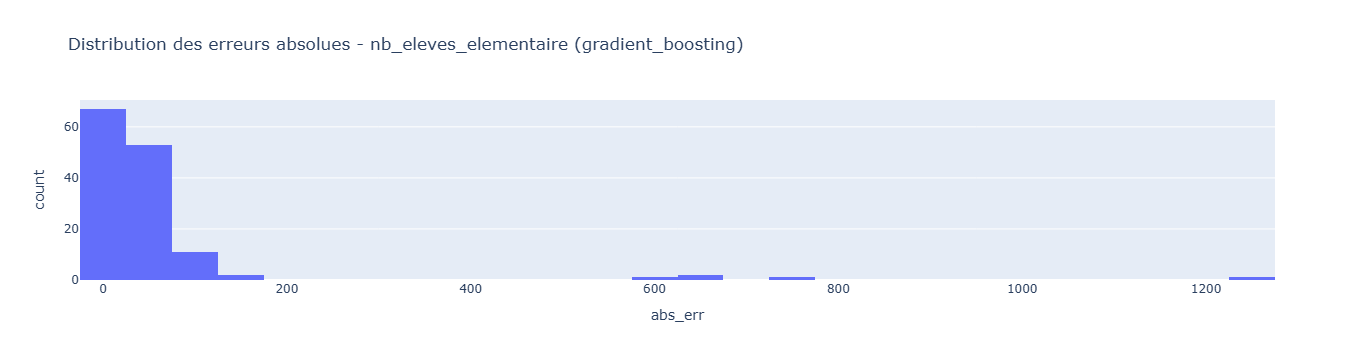

,y_true,y_pred,abs_err
count,138.000000,138.000000,138.000000
mean,740.869565,743.895104,59.174943
std,1931.725218,1919.929853,148.492848
min,40.000000,49.406166,0.303341
25%,151.750000,156.615331,8.815382
50%,327.000000,338.833642,26.726126
75%,569.250000,576.337952,44.972318
max,11265.000000,10531.903051,1225.903051


In [6]:
target_focus = 'nb_eleves_elementaire'
winner = results[results['target'] == target_focus].sort_values('r2', ascending=False).iloc[0]['model']

model = get_model_candidates()[winner]
y = df[target_focus].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
pred = model.predict(X_test)

errors = pd.DataFrame({'y_true': y_test, 'y_pred': pred})
errors['abs_err'] = (errors['y_true'] - errors['y_pred']).abs()

fig_err = px.histogram(errors, x='abs_err', nbins=30, title=f'Distribution des erreurs absolues - {target_focus} ({winner})')
fig_err.show()
errors.describe()

## Analyse de la distribution des erreurs

L'histogramme montre la répartition des **erreurs absolues** (|ŷ − y|) du meilleur modèle sur `nb_eleves_elementaire`.

**Ce qu'on cherche :**
- Une distribution **concentrée vers 0** → le modèle est précis sur la majorité des communes.
- Une queue longue à droite → quelques communes difficiles à prédire (communes en forte croissance, données atypiques).

**Seuils indicatifs pour ce projet :**
| Erreur absolue | Interprétation opérationnelle |
|---|---|
| < 20 élèves | Excellent — précision suffisante pour planifier 1 classe |
| 20 – 50 élèves | Acceptable — marge d'incertitude à communiquer |
| > 50 élèves | À surveiller — peut impacter l'ouverture/fermeture d'une classe entière |

> Les communes avec les erreurs les plus fortes sont souvent celles qui ont connu un **boom démographique récent** non encore reflété dans les features historiques.